In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel

fw = pd.read_feather("binary_fedwatch.feather")
pm = pd.read_feather("pm_meeting_whole.feather")
realized = pd.read_excel("fomc_realized_from_fed_policy.xlsx")

### Data

In [2]:
fw.head()

,meeting_raw,meeting,date,exp_hikes_cuts,meeting_date,rate_change_bps,rate_change_25bp,days_to_meeting,prev_meeting,prev_meeting_date,prev_exp_hikes_cuts,fed_implied_change_25bp,fed_implied_change_bps,p_cut_fw,p_hike_fw,p_nochange_fw
0,US0ANM DEC2023 Index,DEC2023,2022-06-24,6.426,2023-12-13,0.0,0.0,537,NOV2023,2023-11-01,6.603,-0.177,-4.425,0.177,0.0,0.823
1,US0ANM DEC2023 Index,DEC2023,2022-06-27,6.522,2023-12-13,0.0,0.0,534,NOV2023,2023-11-01,6.730,-0.208,-5.200,0.208,0.0,0.792
2,US0ANM DEC2023 Index,DEC2023,2022-06-28,6.458,2023-12-13,0.0,0.0,533,NOV2023,2023-11-01,6.661,-0.203,-5.075,0.203,0.0,0.797
3,US0ANM DEC2023 Index,DEC2023,2022-06-29,6.026,2023-12-13,0.0,0.0,532,NOV2023,2023-11-01,6.318,-0.292,-7.300,0.292,0.0,0.708
4,US0ANM DEC2023 Index,DEC2023,2022-06-30,5.409,2023-12-13,0.0,0.0,531,NOV2023,2023-11-01,5.724,-0.315,-7.875,0.315,0.0,0.685


In [3]:
pm.head()

,meeting,meeting_date,date,days_to_meeting,+25,+50,+75,-25,-50,0,...,n_markets,n_special_markets,pm_implied_mean_bps,pm_max_prob,pm_entropy,rate_change_bps,rate_change_25bp,p_cut,p_hike,p_nochange
0,APR2026,2026-04-29,2025-11-13,167,NaN,NaN,NaN,0.270,NaN,0.630,...,4,2,-9.808612,0.630,1.018007,NaN,NaN,0.349282,0.047847,0.602871
1,APR2026,2026-04-29,2025-11-14,166,NaN,NaN,NaN,0.300,NaN,0.620,...,4,2,-10.495283,0.620,1.020742,NaN,NaN,0.372642,0.042453,0.584906
2,APR2026,2026-04-29,2025-11-15,165,NaN,NaN,NaN,0.290,NaN,0.620,...,4,2,-9.834123,0.620,1.031604,NaN,NaN,0.360190,0.052133,0.587678
3,APR2026,2026-04-29,2025-11-16,164,NaN,NaN,NaN,0.305,NaN,0.600,...,4,2,-9.830097,0.600,1.012722,NaN,NaN,0.368932,0.048544,0.582524
4,APR2026,2026-04-29,2025-11-17,163,NaN,NaN,NaN,0.300,NaN,0.595,...,4,2,-10.386473,0.595,1.036614,NaN,NaN,0.376812,0.048309,0.574879


In [4]:
pm.columns

Index(['meeting', 'meeting_date', 'date', 'days_to_meeting', '+25', '+50',
       '+75', '-25', '-50', '0', '<=-50', '<=-75', '>=+25', '>=+50', 'other',
       'n_markets', 'n_special_markets', 'pm_implied_mean_bps', 'pm_max_prob',
       'pm_entropy', 'rate_change_bps', 'rate_change_25bp', 'p_cut', 'p_hike',
       'p_nochange'],
      dtype='object')

In [5]:
# expected mean change for fw
# fw['fed_implied_change_25bp']

# expected mean change for pm
pm['pm_implied_change_bps'] = (
    pm["+25"].fillna(0) * 25
    + pm["+50"].fillna(0) * 50
    + pm["+75"].fillna(0) * 75
    + pm[">=+25"].fillna(0) * 25
    + pm[">=+50"].fillna(0) * 50
    - pm["-25"].fillna(0) * 25
    - pm["-50"].fillna(0) * 50
    - pm["<=-50"].fillna(0) * 50
    - pm["<=-75"].fillna(0) * 75
)

In [6]:
# Var for fw
def fw_var(x):
    if pd.isna(x):
        return np.nan
    
    low = np.floor(x)
    high = np.ceil(x)
    
    # 如果正好是整数，比如 -1, 0, 1
    if low == high:
        return 0.0
    
    # 两点分布概率
    p_low = high - x
    p_high = x - low
    
    # 支持点
    values = np.array([low, high], dtype=float)
    probs = np.array([p_low, p_high], dtype=float)
    
    # 这里均值其实就是 x
    var = np.sum(probs * (values - x) ** 2)
    
    return var

fw["fw_var"] = fw["fed_implied_change_25bp"].apply(fw_var)

In [7]:
# Var for pm
def pm_var_given_mean(row):
    values = np.array([25, 50, 75, 25, 50, -25, -50, -50, -75], dtype=float)
    probs = np.array([
        row["+25"] if pd.notna(row["+25"]) else 0,
        row["+50"] if pd.notna(row["+50"]) else 0,
        row["+75"] if pd.notna(row["+75"]) else 0,
        row[">=+25"] if pd.notna(row[">=+25"]) else 0,
        row[">=+50"] if pd.notna(row[">=+50"]) else 0,
        row["-25"] if pd.notna(row["-25"]) else 0,
        row["-50"] if pd.notna(row["-50"]) else 0,
        row["<=-50"] if pd.notna(row["<=-50"]) else 0,
        row["<=-75"] if pd.notna(row["<=-75"]) else 0,
    ], dtype=float)

    total = probs.sum()
    if total == 0 or pd.isna(row["pm_implied_change_bps"]):
        return np.nan

    probs = probs / total
    mean = row["pm_implied_change_bps"]
    return np.sum(probs * (values - mean) ** 2)

pm["pm_var"] = pm.apply(pm_var_given_mean, axis=1)

In [8]:
fw.head()

,meeting_raw,meeting,date,exp_hikes_cuts,meeting_date,rate_change_bps,rate_change_25bp,days_to_meeting,prev_meeting,prev_meeting_date,prev_exp_hikes_cuts,fed_implied_change_25bp,fed_implied_change_bps,p_cut_fw,p_hike_fw,p_nochange_fw,fw_var
0,US0ANM DEC2023 Index,DEC2023,2022-06-24,6.426,2023-12-13,0.0,0.0,537,NOV2023,2023-11-01,6.603,-0.177,-4.425,0.177,0.0,0.823,0.145671
1,US0ANM DEC2023 Index,DEC2023,2022-06-27,6.522,2023-12-13,0.0,0.0,534,NOV2023,2023-11-01,6.730,-0.208,-5.200,0.208,0.0,0.792,0.164736
2,US0ANM DEC2023 Index,DEC2023,2022-06-28,6.458,2023-12-13,0.0,0.0,533,NOV2023,2023-11-01,6.661,-0.203,-5.075,0.203,0.0,0.797,0.161791
3,US0ANM DEC2023 Index,DEC2023,2022-06-29,6.026,2023-12-13,0.0,0.0,532,NOV2023,2023-11-01,6.318,-0.292,-7.300,0.292,0.0,0.708,0.206736
4,US0ANM DEC2023 Index,DEC2023,2022-06-30,5.409,2023-12-13,0.0,0.0,531,NOV2023,2023-11-01,5.724,-0.315,-7.875,0.315,0.0,0.685,0.215775


In [9]:
# 1. 统一格式
for df in [fw, pm, realized]:
    if "meeting" in df.columns:
        df["meeting"] = df["meeting"].astype(str).str.upper().str.strip()
for df in [fw, pm]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"]).dt.normalize()

df = pm.merge(
    fw,
    on=["meeting", "date"],
    how="inner",
    suffixes=("_pm", "_fw")
)

In [10]:
realized["Y_cut"] = (realized["rate_change"] < 0).astype(int)

df = df.merge(
    realized[["meeting", "rate_change", "Y_cut"]],
    on="meeting",
    how="left"
)

rename_map = {}

if "p_cut" in df.columns:
    rename_map["p_cut"] = "p_cut_pm"
if "p_hike" in df.columns:
    rename_map["p_hike"] = "p_hike_pm"
if "p_nochange" in df.columns:
    rename_map["p_nochange"] = "p_nochange_pm"

df = df.rename(columns=rename_map)

In [11]:
df.head()

,meeting,meeting_date_pm,date,days_to_meeting_pm,+25,+50,+75,-25,-50,0,...,prev_meeting_date,prev_exp_hikes_cuts,fed_implied_change_25bp,fed_implied_change_bps,p_cut_fw,p_hike_fw,p_nochange_fw,fw_var,rate_change,Y_cut
0,DEC2023,2023-12-13,2023-10-23,51,0.185,NaN,NaN,NaN,NaN,0.80,...,2023-11-01,0.016,0.212,5.300,0.0,0.212,0.788,0.167056,0.0,0.0
1,DEC2023,2023-12-13,2023-10-24,50,0.180,NaN,NaN,NaN,NaN,0.81,...,2023-11-01,0.016,0.239,5.975,0.0,0.239,0.761,0.181879,0.0,0.0
2,DEC2023,2023-12-13,2023-10-25,49,0.180,NaN,NaN,NaN,NaN,0.81,...,2023-11-01,0.016,0.239,5.975,0.0,0.239,0.761,0.181879,0.0,0.0
3,DEC2023,2023-12-13,2023-10-26,48,0.140,NaN,NaN,NaN,NaN,0.50,...,2023-11-01,0.016,0.175,4.375,0.0,0.175,0.825,0.144375,0.0,0.0
4,DEC2023,2023-12-13,2023-10-27,47,0.155,NaN,NaN,NaN,NaN,0.50,...,2023-11-01,-0.005,0.168,4.200,0.0,0.168,0.832,0.139776,0.0,0.0


In [12]:
df.columns

Index(['meeting', 'meeting_date_pm', 'date', 'days_to_meeting_pm', '+25',
       '+50', '+75', '-25', '-50', '0', '<=-50', '<=-75', '>=+25', '>=+50',
       'other', 'n_markets', 'n_special_markets', 'pm_implied_mean_bps',
       'pm_max_prob', 'pm_entropy', 'rate_change_bps_pm',
       'rate_change_25bp_pm', 'p_cut_pm', 'p_hike_pm', 'p_nochange_pm',
       'pm_implied_change_bps', 'pm_var', 'meeting_raw', 'exp_hikes_cuts',
       'meeting_date_fw', 'rate_change_bps_fw', 'rate_change_25bp_fw',
       'days_to_meeting_fw', 'prev_meeting', 'prev_meeting_date',
       'prev_exp_hikes_cuts', 'fed_implied_change_25bp',
       'fed_implied_change_bps', 'p_cut_fw', 'p_hike_fw', 'p_nochange_fw',
       'fw_var', 'rate_change', 'Y_cut'],
      dtype='object')

In [13]:
final_cols = [
    col for col in [
        "meeting",
        "meeting_date_pm",
        "date",
        "days_to_meeting_pm",
        "p_cut_pm",
        "p_hike_pm",
        "p_nochange_pm",
        "p_cut_fw",
        "p_hike_fw",
        "p_nochange_fw",
        'pm_implied_mean_bps',
        'fed_implied_change_bps',
        'pm_var',
        'fw_var',
        'rate_change',
        "Y_cut"
    ] if col in df.columns
]

df_simple = df[final_cols].copy()


In [14]:
df_simple["spread"] = df_simple["p_cut_pm"] - df_simple["p_cut_fw"]
df_simple["ret_pm"] = df_simple["Y_cut"] - df_simple["p_cut_pm"]

df_simple["spread_mean"] = df_simple["pm_implied_mean_bps"] - df_simple["fed_implied_change_bps"]
df_simple["spread_var"] = df_simple["pm_var"] - df_simple["fw_var"]


In [15]:
df_simple.columns

Index(['meeting', 'meeting_date_pm', 'date', 'days_to_meeting_pm', 'p_cut_pm',
       'p_hike_pm', 'p_nochange_pm', 'p_cut_fw', 'p_hike_fw', 'p_nochange_fw',
       'pm_implied_mean_bps', 'fed_implied_change_bps', 'pm_var', 'fw_var',
       'rate_change', 'Y_cut', 'spread', 'ret_pm', 'spread_mean',
       'spread_var'],
      dtype='object')

In [16]:
df_simple = df_simple[["ret_pm", "spread", "spread_mean", "spread_var", "days_to_meeting_pm", "meeting"]].dropna().copy()

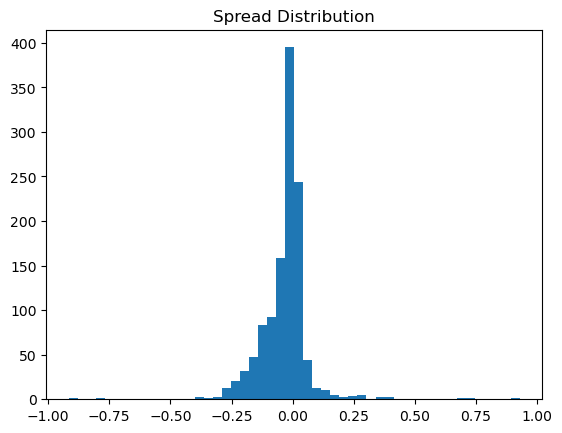

In [17]:
plt.hist(df_simple["spread"], bins=50)
plt.title("Spread Distribution")
plt.show()

### Model 1 - Distribution-Based Regression

In [18]:
reg1 = smf.ols(
    "ret_pm ~ spread + C(days_to_meeting_pm)",
    data=df_simple
).fit(cov_type="cluster", cov_kwds={"groups": df_simple["meeting"]})

print(reg1.summary())

                            OLS Regression Results                            
Dep. Variable:                 ret_pm   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                 -0.041
Method:                 Least Squares   F-statistic:                 1.827e+10
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          2.81e-103
Time:                        11:54:45   Log-Likelihood:                -454.95
No. Observations:                1185   AIC:                             1134.
Df Residuals:                    1073   BIC:                             1703.
Df Model:                         111                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

c:\Users\74594\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 111, but rank is 22
  warnings.warn('covariance of constraints does not have full '


In [18]:
res = reg1

coef = res.params["spread"]
pval = res.pvalues["spread"]
tstat = res.tvalues["spread"]

print("coef:", coef)
print("t-stat:", tstat)
print("p-value:", pval)

coef: 0.6266468976982758
t-stat: 1.0580736455565072
p-value: 0.2900218684187439


In [19]:
df_sub = df_simple[df_simple["days_to_meeting_pm"].between(0, 30)]

reg2 = smf.ols(
    "ret_pm ~ spread + C(days_to_meeting_pm)",
    data=df_sub
).fit(cov_type="cluster", cov_kwds={"groups": df_sub["meeting"]})

print(reg2.summary())

                            OLS Regression Results                            
Dep. Variable:                 ret_pm   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     119.3
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           2.78e-17
Time:                        21:39:00   Log-Likelihood:                -154.38
No. Observations:                 482   AIC:                             364.8
Df Residuals:                     454   BIC:                             481.7
Df Model:                          27                                         
Covariance Type:              cluster                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

c:\Users\74594\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 20
  warnings.warn('covariance of constraints does not have full '


In [20]:
res = reg2

coef = res.params["spread"]
pval = res.pvalues["spread"]
tstat = res.tvalues["spread"]

print("coef:", coef)
print("t-stat:", tstat)
print("p-value:", pval)

coef: 3.863834593546245
t-stat: 2.0780319811356223
p-value: 0.03770641364298397


In [24]:
df_sub = df_simple[df_simple["days_to_meeting_pm"].between(0, 30)]

reg2 = smf.ols(
    "ret_pm ~ spread",
    data=df_sub
).fit(cov_type="cluster", cov_kwds={"groups": df_sub["meeting"]})

print(reg2.summary())

                            OLS Regression Results                            
Dep. Variable:                 ret_pm   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     3.558
Date:                Sat, 18 Apr 2026   Prob (F-statistic):             0.0732
Time:                        21:39:37   Log-Likelihood:                -163.69
No. Observations:                 482   AIC:                             331.4
Df Residuals:                     480   BIC:                             339.7
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0354      0.070     -0.507      0.6

### Model 2 - Ordered Logit

In [ ]:
reg_df = df[[
    "rate_change",
    "pm_implied_mean_bps",
    "fed_implied_change_bps",
    "pm_var",
    "fw_var",
    "days_to_meeting_pm"
]].dropna().copy()

# X
X = reg_df[[
    "pm_implied_mean_bps",
    "fed_implied_change_bps",
    "pm_var",
    "fw_var"
]]

y = reg_df["rate_change"]

In [22]:
model = OrderedModel(
    y,
    X,
    distr="logit"
)

res = model.fit(method="bfgs")

Optimization terminated successfully.
         Current function value: 0.692251
         Iterations: 35
         Function evaluations: 41
         Gradient evaluations: 41


In [23]:
print(res.summary())

                             OrderedModel Results                             
Dep. Variable:            rate_change   Log-Likelihood:                -820.32
Model:                   OrderedModel   AIC:                             1657.
Method:            Maximum Likelihood   BIC:                             1697.
Date:                Mon, 27 Apr 2026                                         
Time:                        11:58:00                                         
No. Observations:                1185                                         
Df Residuals:                    1177                                         
Df Model:                           4                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
pm_implied_mean_bps        0.3327      0.023     14.655      0.000       0.288       0.377
fed_implied_chan

In [26]:
reg_df_sub = reg_df[reg_df["days_to_meeting_pm"].between(0, 30)]

X_sub = reg_df_sub[[
    "pm_implied_mean_bps",
    "fed_implied_change_bps",
    "pm_var",
    "fw_var"
]]

y_sub = reg_df_sub["rate_change"]

model = OrderedModel(
    y_sub,
    X_sub,
    distr="logit"
)

res_sub = model.fit(method="bfgs")

print(res_sub.summary())

Optimization terminated successfully.
         Current function value: 0.795835
         Iterations: 38
         Function evaluations: 41
         Gradient evaluations: 41
                             OrderedModel Results                             
Dep. Variable:            rate_change   Log-Likelihood:                -383.59
Model:                   OrderedModel   AIC:                             783.2
Method:            Maximum Likelihood   BIC:                             816.6
Date:                Mon, 27 Apr 2026                                         
Time:                        12:00:54                                         
No. Observations:                 482                                         
Df Residuals:                     474                                         
Df Model:                           4                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

In [27]:
X_sub2 = reg_df_sub[[
    "pm_implied_mean_bps",
    "fed_implied_change_bps",
    "pm_var",
    "fw_var",
    "days_to_meeting_pm"
]]

y_sub2 = reg_df_sub["rate_change"]

model = OrderedModel(
    y_sub2,
    X_sub2,
    distr="logit"
)

res_sub2 = model.fit(method="bfgs")

print(res_sub2.summary())

Optimization terminated successfully.
         Current function value: 0.777131
         Iterations: 38
         Function evaluations: 42
         Gradient evaluations: 42
                             OrderedModel Results                             
Dep. Variable:            rate_change   Log-Likelihood:                -374.58
Model:                   OrderedModel   AIC:                             767.2
Method:            Maximum Likelihood   BIC:                             804.8
Date:                Mon, 27 Apr 2026                                         
Time:                        12:01:34                                         
No. Observations:                 482                                         
Df Residuals:                     473                                         
Df Model:                           5                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------